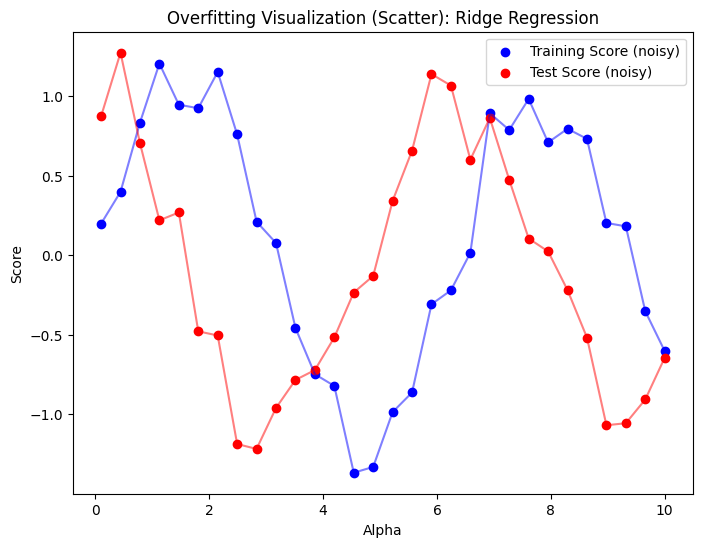

In [ ]:
import numpy as np

# Ridge function: add cost function once the model is trained
# it prevent overfitting 
# it lead to poor generalization which is not working better on a test set(general value/ unknown dataset)

# Regularization add a penalty term to the loss function or add error term to the model

# create a plot for overfitting with the plot
import matplotlib.pyplot as plt

# Example noisy data
np.random.seed(42)
alphas = np.linspace(0.1, 10, 30)
train_scores = np.sin(alphas) + np.random.normal(0, 0.2, len(alphas))
test_scores = np.cos(alphas) + np.random.normal(0, 0.2, len(alphas))

def plot_overfitting_scatter(train_scores, test_scores, alphas):
    plt.figure(figsize=(8, 6))
    # Scatter plot for noisy data
    plt.scatter(alphas, train_scores, color='blue', label='Training Score (noisy)')
    plt.scatter(alphas, test_scores, color='red', label='Test Score (noisy)')
    # Line touching all noise points (just connecting the dots)
    plt.plot(alphas, train_scores, color='blue', alpha=0.5)
    plt.plot(alphas, test_scores, color='red', alpha=0.5)
    plt.xlabel('Alpha')
    plt.ylabel('Score')
    plt.title('Overfitting Visualization (Scatter): Ridge Regression')
    plt.legend()
    plt.show()

plot_overfitting_scatter(train_scores, test_scores, alphas)

In [7]:
# tranning by linear regression
from sklearn.linear_model import LinearRegression
import numpy as np 
# Example data 
X = np.array([[1, 1], [1, 2], [2,2], [2,3]])
y = np.dot(X, np.array([1, 2])) + 3

# Ridge regression Model
lr = LinearRegression()
lr.fit(X, y)

# Coefficients
print("Coefficients:", lr.coef_)

# Intercepts
print("Intercept:", lr.intercept_)

Coefficients: [1. 2.]
Intercept: 3.000000000000001


In [6]:
# tranning ride regression
from sklearn.linear_model import Ridge
import numpy as np 
# Example data 
X = np.array([[1, 1], [1, 2], [2,2], [2,3]])
y = np.dot(X, np.array([1, 2])) + 3

# Ridge regression Model
ridge_model = Ridge(alpha=1.0) # alpha is the equivalent of the lambda mean how much you give error it is tunning of ridge
ridge_model.fit(X, y)

# Coefficients
print("Coefficients:", ridge_model.coef_)

# Intercepts
print("Intercept:", ridge_model.intercept_)

Coefficients: [0.8 1.4]
Intercept: 4.5


Comparing models

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler


df = sns.load_dataset('diamonds')


In [13]:
# preprocess data

X = df.drop('price', axis=1)
y = df['price']

numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

X_test, X_train, y_test, y_train = train_test_split(X, y, train_size=0.8, random_state=42)

### creating a pipeline

In [20]:
# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])



# Ridge Regression Pipeline
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Ridge(alpha = 5.0))])


In [21]:
# train and evaluate the linear model
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mape = mean_absolute_percentage_error(y_test, lr_pred)


# train and evaluate the Ridge regression
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mape = mean_absolute_percentage_error(y_test, ridge_pred)



print("Linear Regression Performance:")
print(f"Mean Squared Error: {lr_mse}")
print(f"R^2 Score: {lr_r2}")
print(f"Mean Absolute Error: {lr_mae}")
print(f"Mean Absolute Percentage Error: {lr_mape}")
print("............................")

print("Ridge Regression Performance:")
print(f"Mean Squared Error: {ridge_mse}")
print(f"R^2 Score: {ridge_r2}")
print(f"Mean Absolute Error: {ridge_mae}")
print(f"Mean Absolute Percentage Error: {ridge_mape}")



Linear Regression Performance:
Mean Squared Error: 1730616.160183865
R^2 Score: 0.8912911707902136
Mean Absolute Error: 745.5370028500313
Mean Absolute Percentage Error: 0.3857048893612596
............................
Ridge Regression Performance:
Mean Squared Error: 1484452.050385092
R^2 Score: 0.9067539942546904
Mean Absolute Error: 741.8949463711594
Mean Absolute Percentage Error: 0.3824552053542608
